Exploratory Data Analysis (EDA)

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

Load Dataset


In [2]:
df = pd.read_csv('/content/Dataset.csv')

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


Shape of Dataset

In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 17379
Columns : 17


Display First & Last Records

In [4]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [5]:
df.tail()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17374,17375,31-12-2012,springer,2012,12,19,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,11,108,119
17375,17376,31-12-2012,springer,2012,12,20,No,1,Working Day,Mist,0.26,0.2576,0.6,0.1642,8,81,89
17376,17377,31-12-2012,springer,2012,12,21,No,1,Working Day,Clear,?,0.2576,0.6,0.1642,7,83,90
17377,17378,31-12-2012,springer,2012,12,22,No,1,Working Day,Clear,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,31-12-2012,springer,2012,12,23,No,1,?,Clear,0.26,0.2727,0.65,0.1343,12,37,49


Dataset Information

In [6]:
df.dtypes

,0
instant,int64
dteday,object
season,object
yr,object
mnth,object
hr,int64
holiday,object
weekday,int64
workingday,object
weathersit,object


Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.0,4345.5,8690.0,13034.5,17379.0
hr,17379.0,11.546752,6.914405,0.0,6.0,12.0,18.0,23.0
weekday,17379.0,3.003683,2.005771,0.0,1.0,3.0,5.0,6.0
cnt,17379.0,189.463088,181.387599,1.0,40.0,142.0,281.0,977.0


Check Missing Values

In [8]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


Percentage of missing values

In [9]:
(df.isnull().sum()/len(df))*100

,0
instant,0.0
dteday,0.0
season,0.0
yr,0.0
mnth,0.0
hr,0.0
holiday,0.0
weekday,0.0
workingday,0.0
weathersit,0.0


Check Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(0)

If duplicates exist

In [11]:
df = df.drop_duplicates()

Verify

In [12]:
df.duplicated().sum()

np.int64(0)

Check Unique Values

In [13]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("----------------")

instant
17379
----------------
dteday
731
----------------
season
5
----------------
yr
3
----------------
mnth
13
----------------
hr
24
----------------
holiday
3
----------------
weekday
7
----------------
workingday
3
----------------
weathersit
5
----------------
temp
51
----------------
atemp
66
----------------
hum
90
----------------
windspeed
31
----------------
casual
323
----------------
registered
777
----------------
cnt
869
----------------


Check Invalid Values

In [14]:
for col in df.columns:
    print("="*50)
    print(col)
    print(df[col].unique()[:20])

instant
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
dteday
['01-01-2011' '02-01-2011' '03-01-2011' '04-01-2011' '05-01-2011'
 '06-01-2011' '07-01-2011' '08-01-2011' '09-01-2011' '10-01-2011'
 '11-01-2011' '12-01-2011' '13-01-2011' '14-01-2011' '15-01-2011'
 '16-01-2011' '17-01-2011' '18-01-2011' '19-01-2011' '20-01-2011']
season
['springer' '?' 'summer' 'fall' 'winter']
yr
['2011' '?' '2012']
mnth
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '?']
hr
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
holiday
['No' 'Yes' '?']
weekday
[6 0 1 2 3 4 5]
workingday
['No work' 'Working Day' '?']
weathersit
['Clear' 'Mist' '?' 'Light Snow' 'Heavy Rain']
temp
['0.24' '0.22' '0.2' '?' '0.38' '0.36' '0.42' '0.46' '0.44' '0.4' '0.34'
 '0.32' '0.3' '0.26' '0.16' '0.14' '0.18' '0.12' '0.28' '0.1']
atemp
['0.2879' '0.2727' '0.2576' '0.3485' '0.3939' '?' '0.4242' '0.4545'
 '0.4394' '0.4091' '0.3333' '0.2273' '0.2121' '0.197' '0.1667' '0.1364'
 '0.1061' '0.1212' '0.18

Dataset Columns

In [15]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Convert Date Column

In [16]:
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  object        
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  object        
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  object        
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  object        
 11  atemp       17379 non-null  object        
 12  hum         17379 non-null  object        
 13  windspeed   17379 non-null  object        
 14  casual      17379 non-null  object        
 15  registered  17379 non-null  object        
 16  cnt         17379 non-

Check Numerical & Categorical Columns

In [17]:
numerical = df.select_dtypes(include=np.number)

categorical = df.select_dtypes(exclude=np.number)

print("Numerical Columns")
print(numerical.columns)

print()

print("Categorical Columns")
print(categorical.columns)

Numerical Columns
Index(['instant', 'hr', 'weekday', 'cnt'], dtype='object')

Categorical Columns
Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit',
       'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered'],
      dtype='object')


Outlier Detection

Boxplots

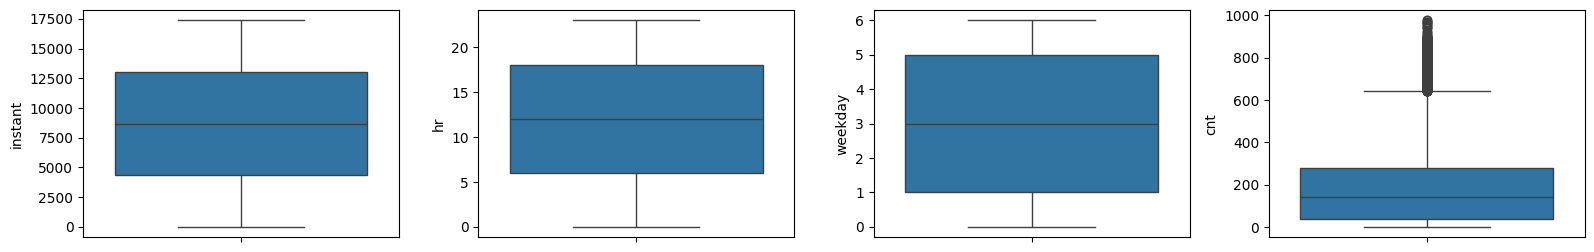

In [18]:
plt.figure(figsize=(20,10))

for i,col in enumerate(numerical.columns):
    plt.subplot(4,5,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

IQR Method

In [19]:
for col in numerical.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col]<lower) | (df[col]>upper)]

    print(col,":",len(outliers))

instant : 0
hr : 0
weekday : 0
cnt : 505


Correlation Matrix

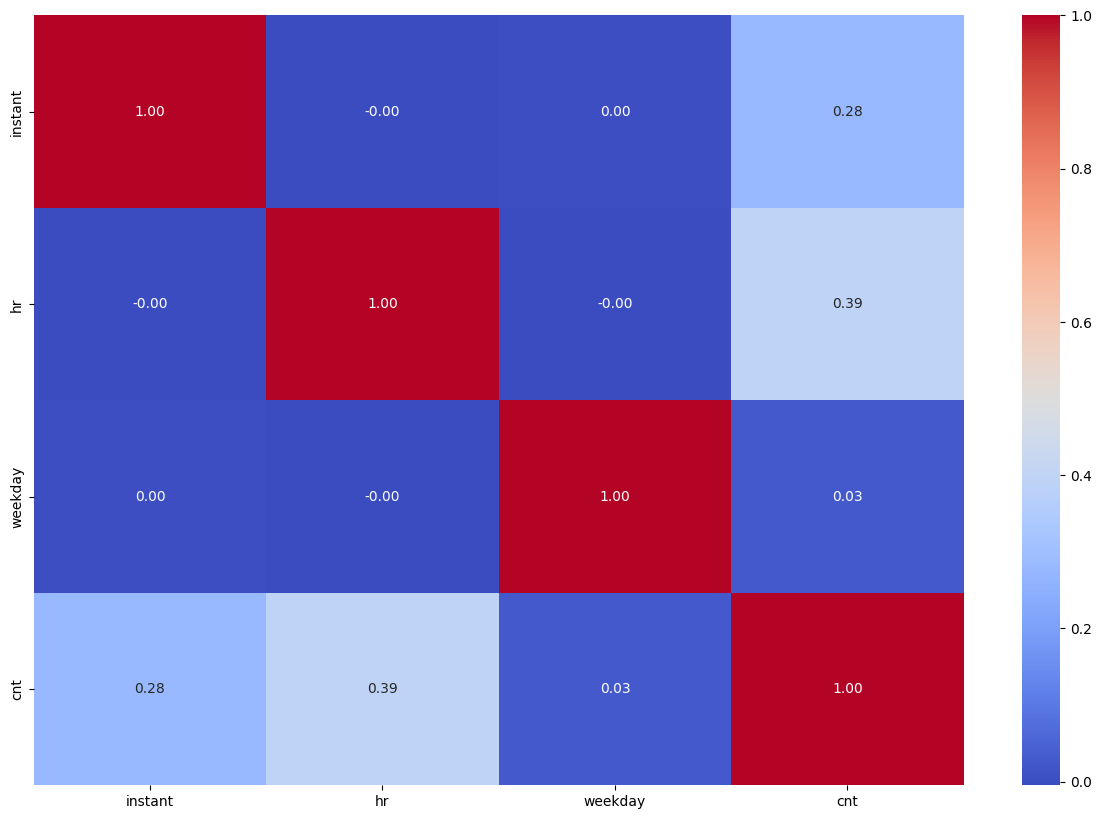

In [20]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.show()

Check Target Variable

In [21]:
df['cnt'].describe()

,cnt
count,17379.000000
mean,189.463088
std,181.387599
min,1.000000
25%,40.000000
50%,142.000000
75%,281.000000
max,977.000000


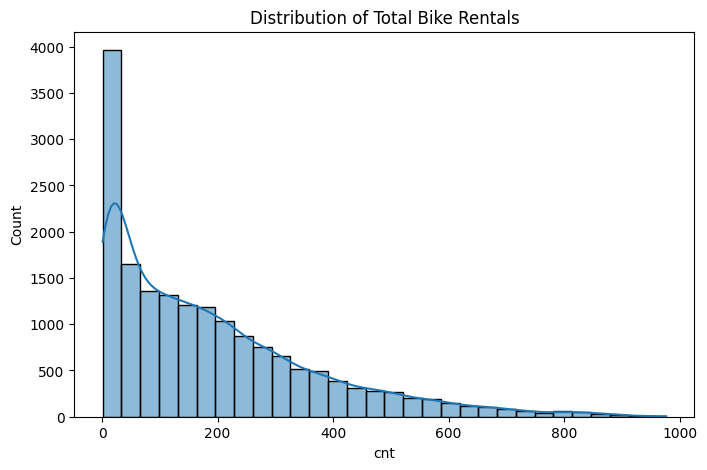

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribution of Total Bike Rentals")
plt.show()

Skewness

In [23]:
df.skew(numeric_only=True)

,0
instant,0.000000
hr,-0.010680
weekday,-0.002998
cnt,1.277412


Final Clean Dataset

In [24]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,2011-01-01,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,2011-01-01,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,2011-01-01,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,2011-01-01,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  object        
 4   mnth        17379 non-null  object        
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  object        
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  object        
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  object        
 11  atemp       17379 non-null  object        
 12  hum         17379 non-null  object        
 13  windspeed   17379 non-null  object        
 14  casual      17379 non-null  object        
 15  registered  17379 non-null  object        
 16  cnt         17379 non-

Data Visualization

Import Libraries

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Distribution of Target Variable (cnt)

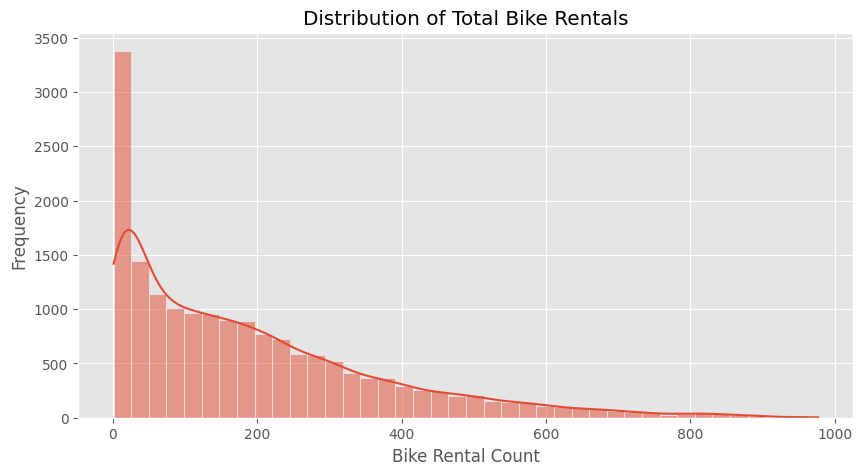

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(df['cnt'], bins=40, kde=True)

plt.title('Distribution of Total Bike Rentals')
plt.xlabel('Bike Rental Count')
plt.ylabel('Frequency')

plt.show()

Season-wise Bike Rentals

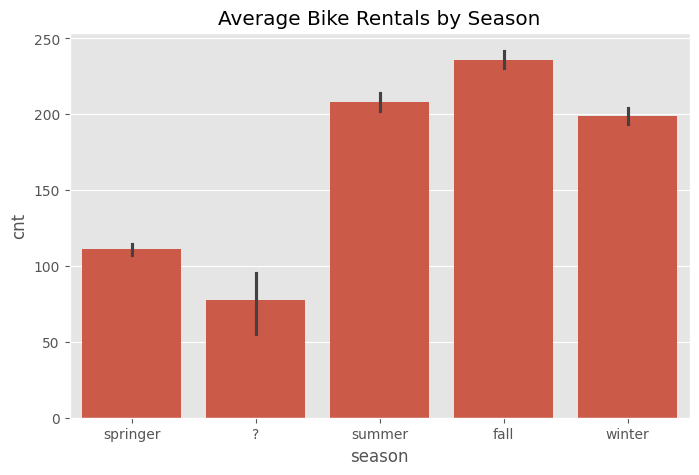

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data=df)
plt.title("Average Bike Rentals by Season")

plt.show()

Month-wise Bike Rentals

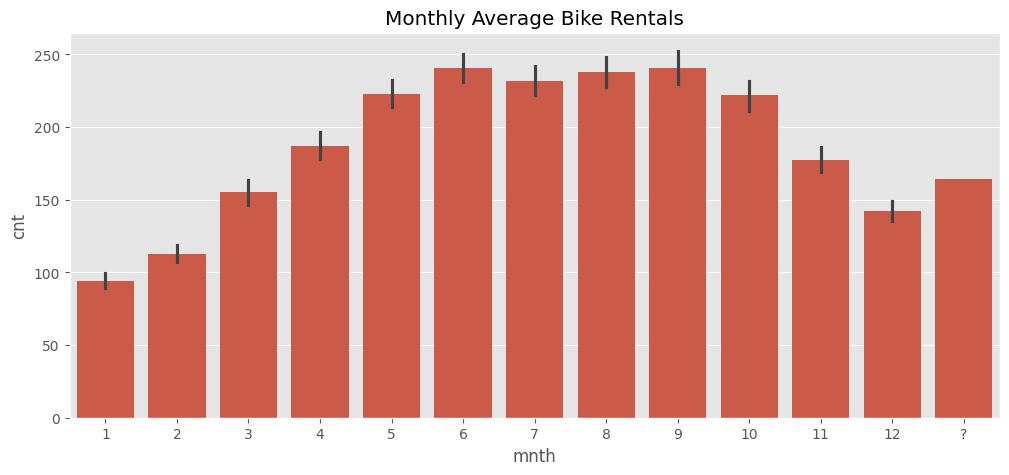

In [29]:
plt.figure(figsize=(12,5))
sns.barplot(x='mnth', y='cnt', data=df)
plt.title("Monthly Average Bike Rentals")

plt.show()

Hour-wise Bike Rentals

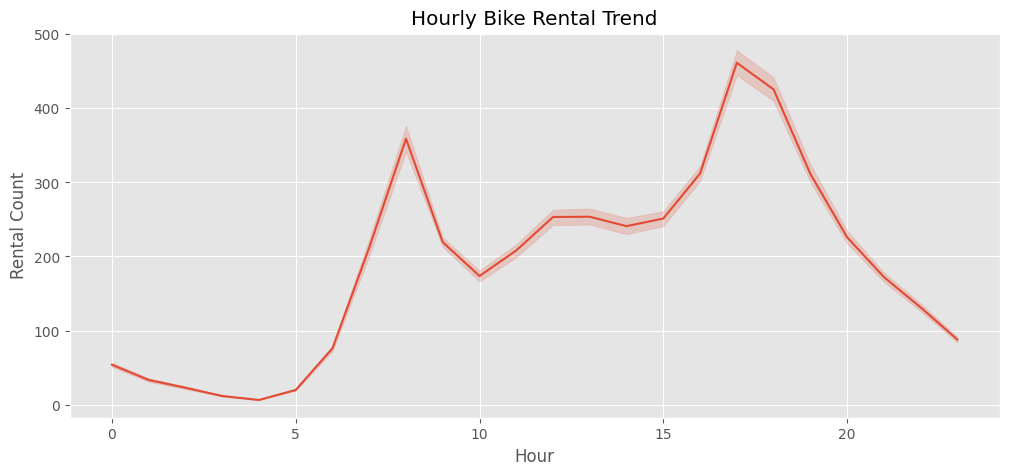

In [30]:
plt.figure(figsize=(12,5))
sns.lineplot(x='hr', y='cnt', data=df)
plt.title("Hourly Bike Rental Trend")
plt.xlabel("Hour")
plt.ylabel("Rental Count")

plt.show()

Working Day vs Rental Count

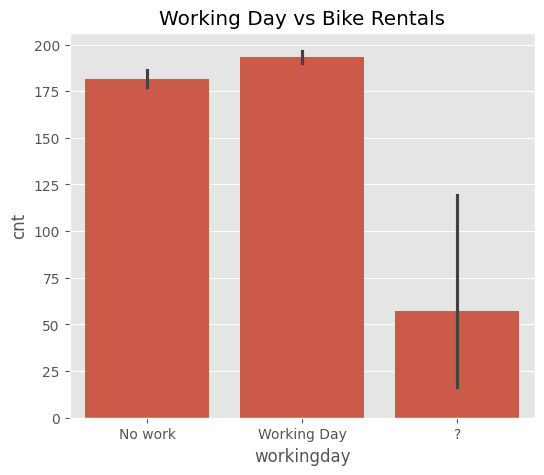

In [31]:
plt.figure(figsize=(6,5))
sns.barplot(x='workingday', y='cnt', data=df)
plt.title("Working Day vs Bike Rentals")

plt.show()

Holiday vs Rental Count

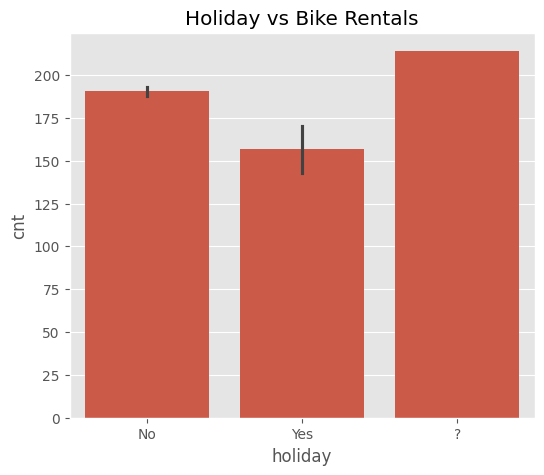

In [32]:
plt.figure(figsize=(6,5))
sns.barplot(x='holiday', y='cnt', data=df)
plt.title("Holiday vs Bike Rentals")

plt.show()

Weather Situation vs Bike Rentals

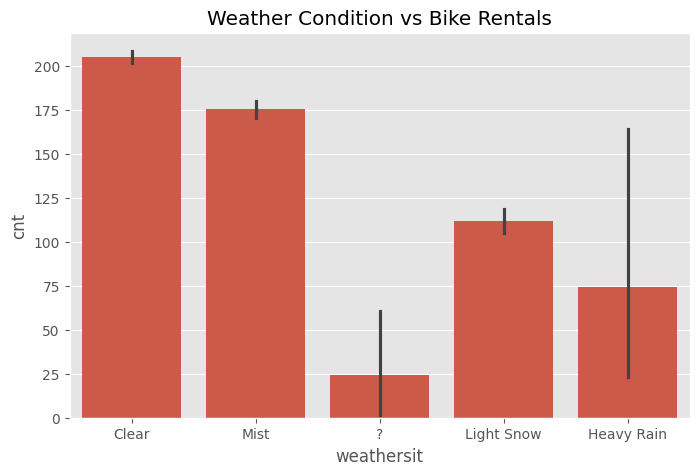

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(x='weathersit', y='cnt', data=df)
plt.title("Weather Condition vs Bike Rentals")

plt.show()

Weekday vs Bike Rentals

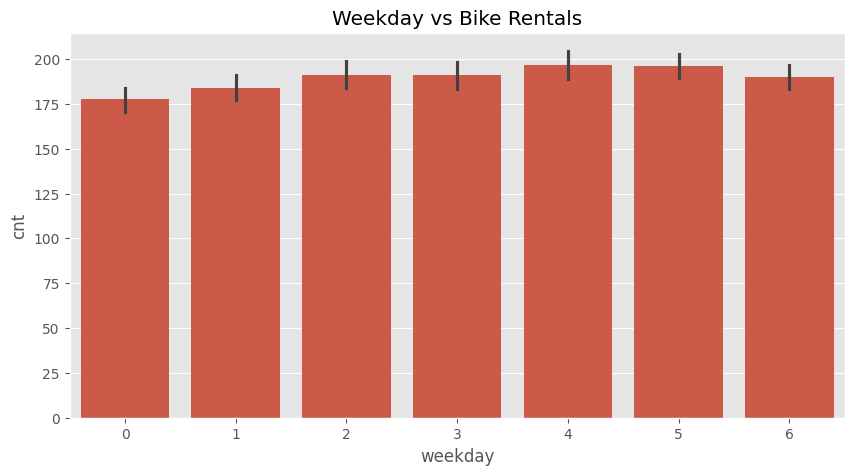

In [34]:
plt.figure(figsize=(10,5))
sns.barplot(x='weekday', y='cnt', data=df)
plt.title("Weekday vs Bike Rentals")

plt.show()

Year-wise Bike Rentals

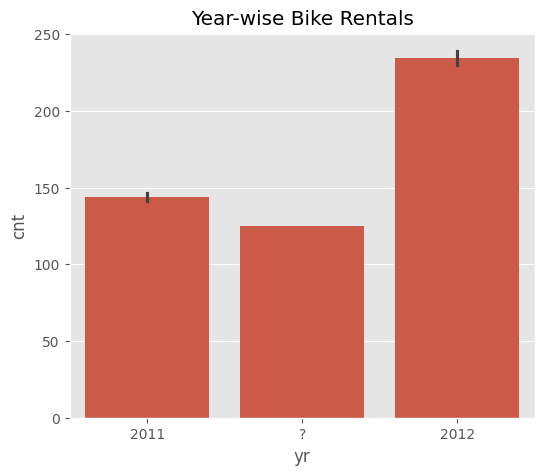

In [35]:
plt.figure(figsize=(6,5))
sns.barplot(x='yr', y='cnt', data=df)
plt.title("Year-wise Bike Rentals")

plt.show()

Scatter Plot - Temperature vs Rentals

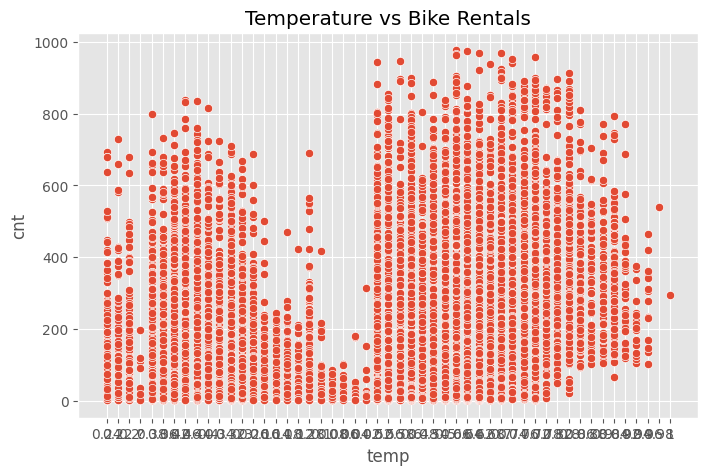

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df)
plt.title("Temperature vs Bike Rentals")

plt.show()

Scatter Plot - Feeling Temperature vs Rentals

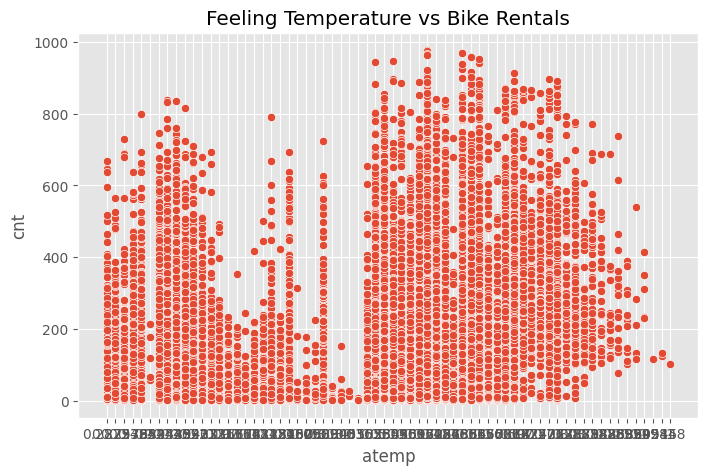

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='atemp', y='cnt', data=df)
plt.title("Feeling Temperature vs Bike Rentals")
plt.show()

Scatter Plot - Humidity vs Rentals

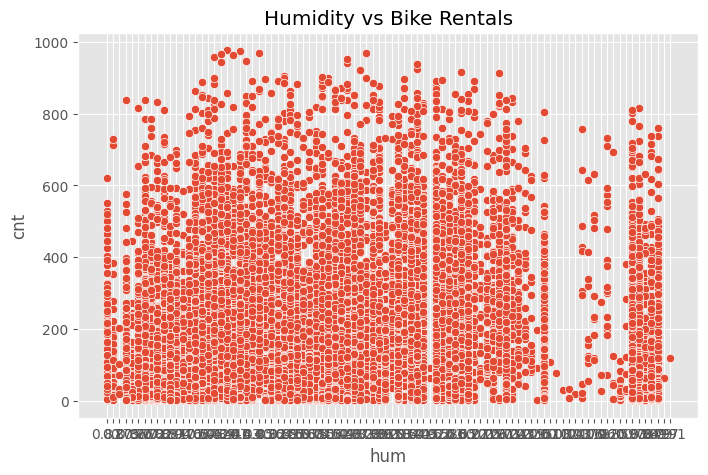

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='hum', y='cnt', data=df)
plt.title("Humidity vs Bike Rentals")

plt.show()

Scatter Plot - Windspeed vs Rentals

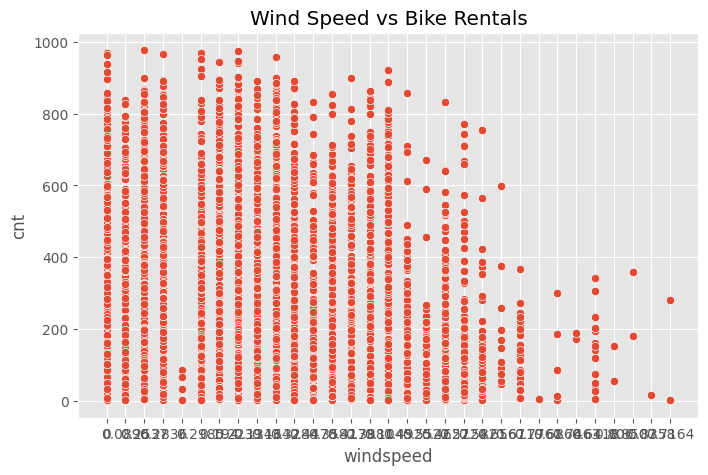

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='windspeed', y='cnt', data=df)
plt.title("Wind Speed vs Bike Rentals")

plt.show()

Pairplot

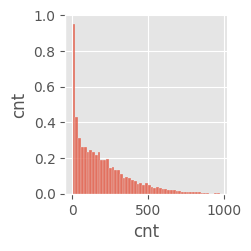

In [40]:
sns.pairplot(df[['temp',
                 'atemp',
                 'hum',
                 'windspeed',
                 'cnt']])

plt.show()

Correlation Heatmap

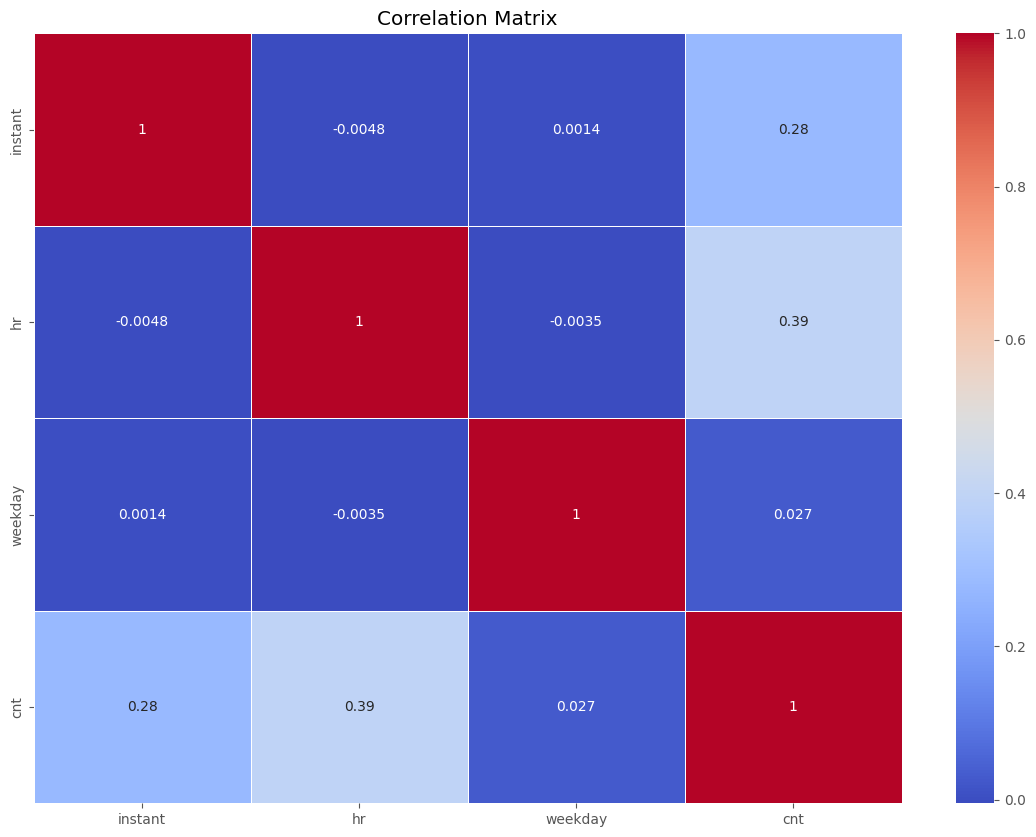

In [41]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Matrix")

plt.show()

Boxplot - Season vs Rentals

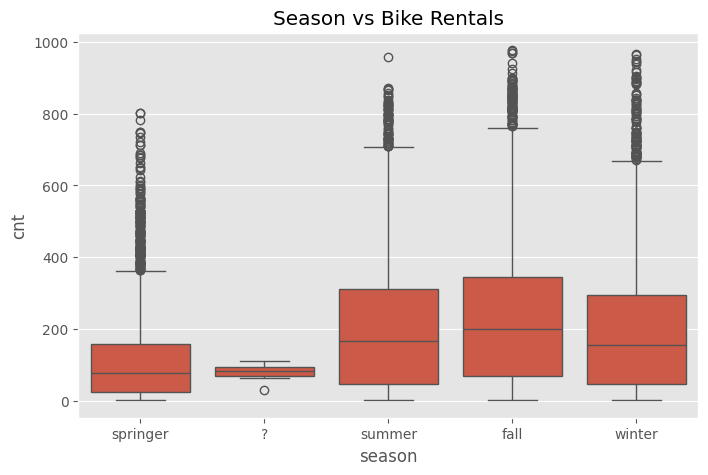

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='cnt', data=df)
plt.title("Season vs Bike Rentals")

plt.show()

Boxplot - Weather vs Rentals

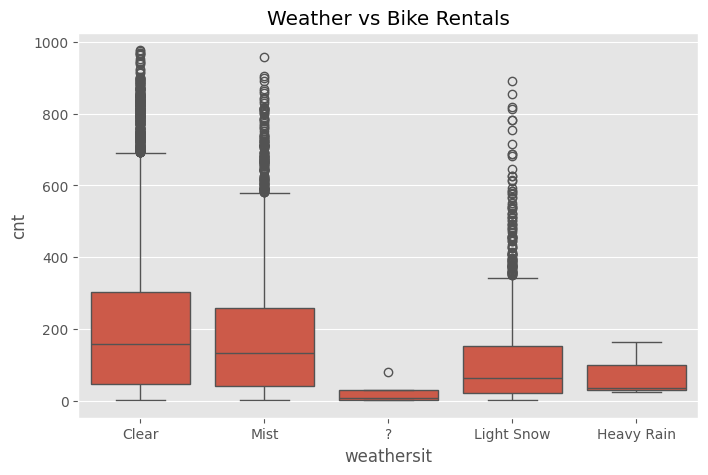

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)
plt.title("Weather vs Bike Rentals")

plt.show()

Boxplot - Month vs Rentals

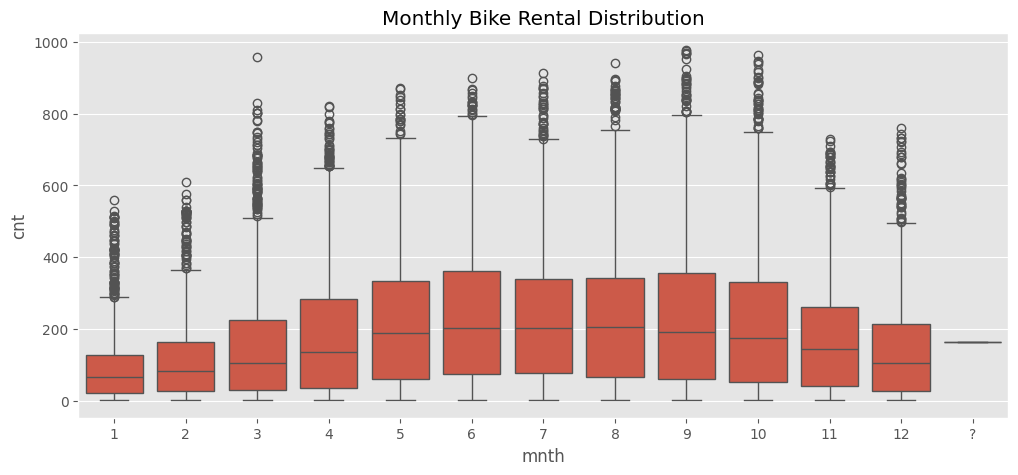

In [45]:
plt.figure(figsize=(12,5))
sns.boxplot(x='mnth', y='cnt', data=df)
plt.title("Monthly Bike Rental Distribution")

plt.show()

Daily Rental Trend (Time Series)

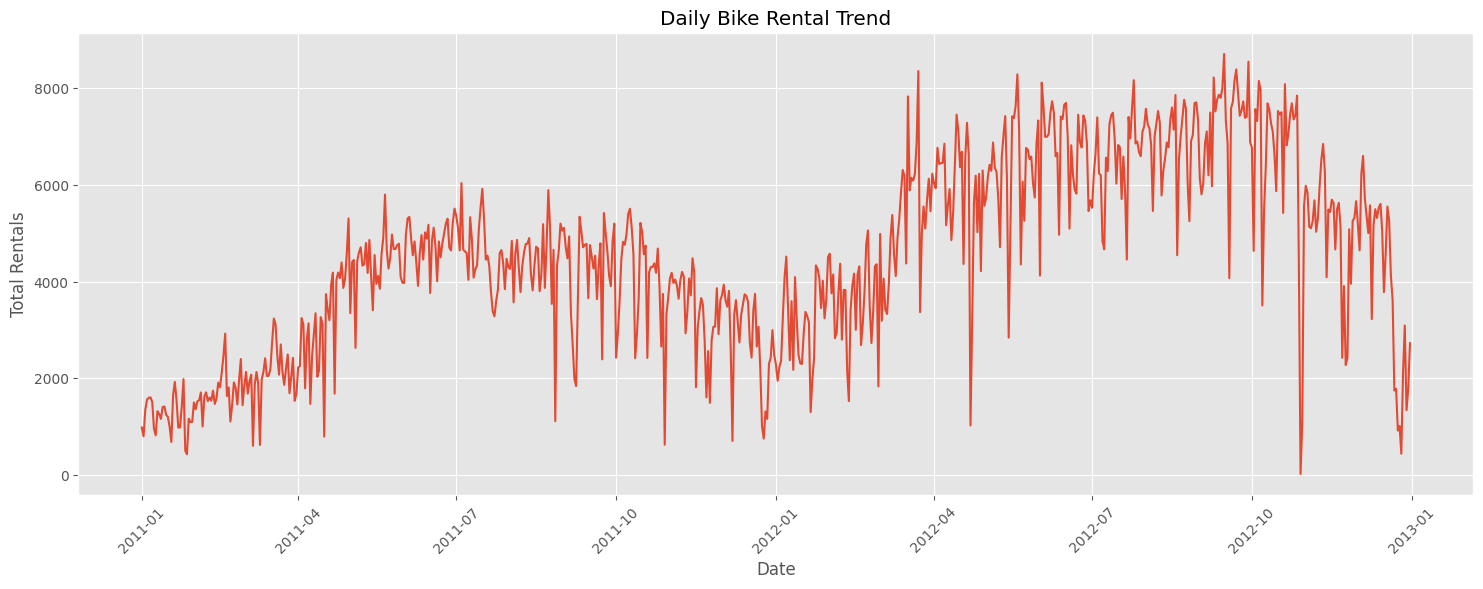

In [46]:
daily_data = df.groupby('dteday')['cnt'].sum().reset_index()

plt.figure(figsize=(18,6))
plt.plot(daily_data['dteday'],
         daily_data['cnt'])
plt.title("Daily Bike Rental Trend")
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.xticks(rotation=45)

plt.show()

Monthly Rental Trend (Time Series)

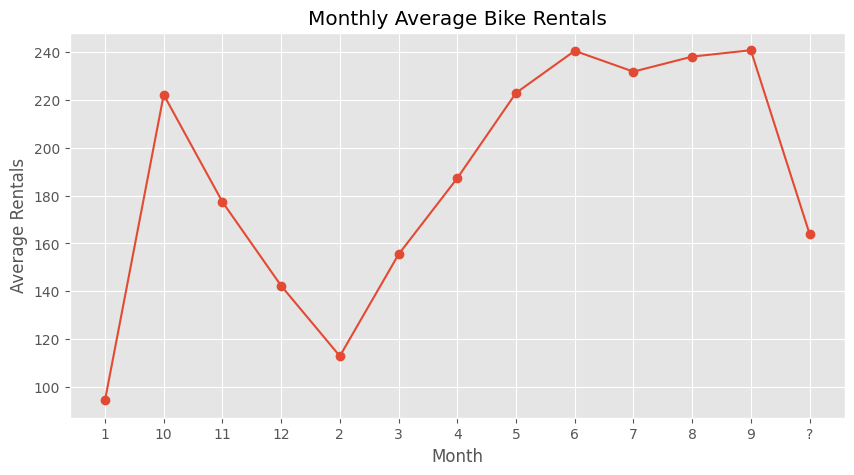

In [47]:
monthly = df.groupby('mnth')['cnt'].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(monthly['mnth'],
         monthly['cnt'],
         marker='o')

plt.title("Monthly Average Bike Rentals")
plt.xlabel("Month")
plt.ylabel("Average Rentals")
plt.grid(True)

plt.show()

Hourly Rental Trend by Working Day

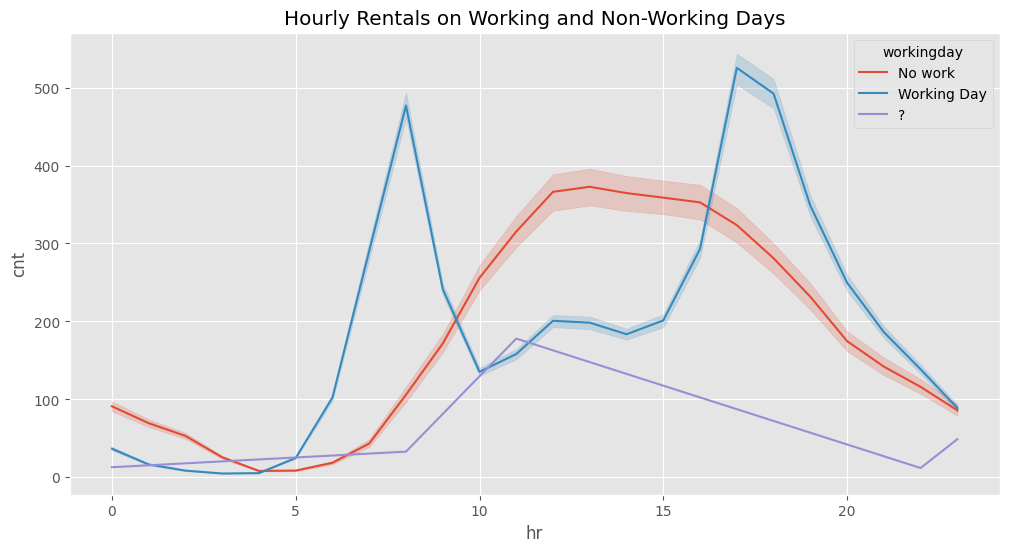

In [48]:
plt.figure(figsize=(12,6))

sns.lineplot(x='hr',
             y='cnt',
             hue='workingday',
             data=df)

plt.title("Hourly Rentals on Working and Non-Working Days")

plt.show()

Hourly Rental Trend by Season

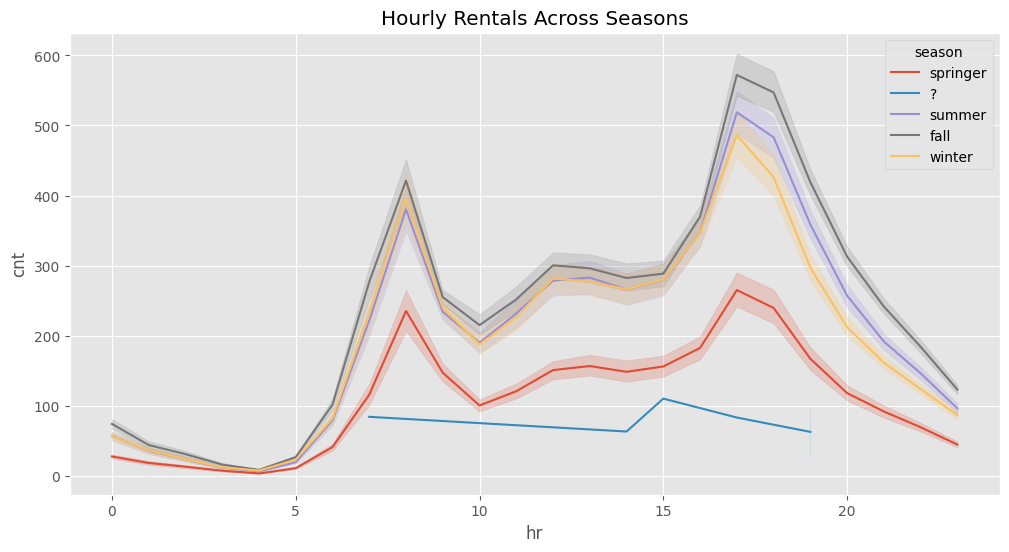

In [49]:
plt.figure(figsize=(12,6))

sns.lineplot(x='hr',
             y='cnt',
             hue='season',
             data=df)

plt.title("Hourly Rentals Across Seasons")

plt.show()

Rental Distribution by Weather

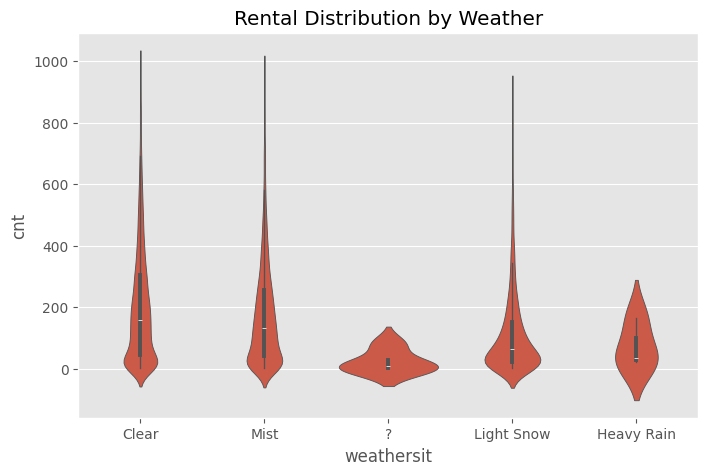

In [50]:
plt.figure(figsize=(8,5))

sns.violinplot(x='weathersit',
               y='cnt',
               data=df)

plt.title("Rental Distribution by Weather")

plt.show()

Registered vs Casual Users

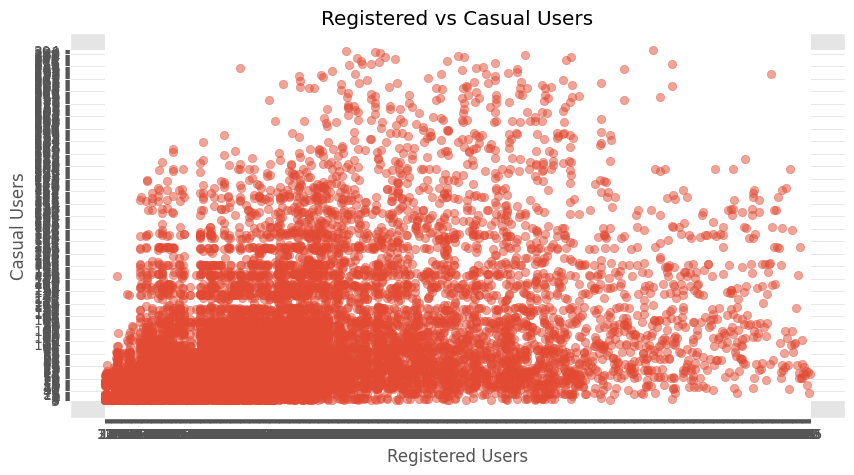

In [51]:
plt.figure(figsize=(10,5))

plt.scatter(df['registered'],
            df['casual'],
            alpha=0.5)

plt.xlabel("Registered Users")
plt.ylabel("Casual Users")
plt.title("Registered vs Casual Users")

plt.show()

Registered, Casual and Total Rentals

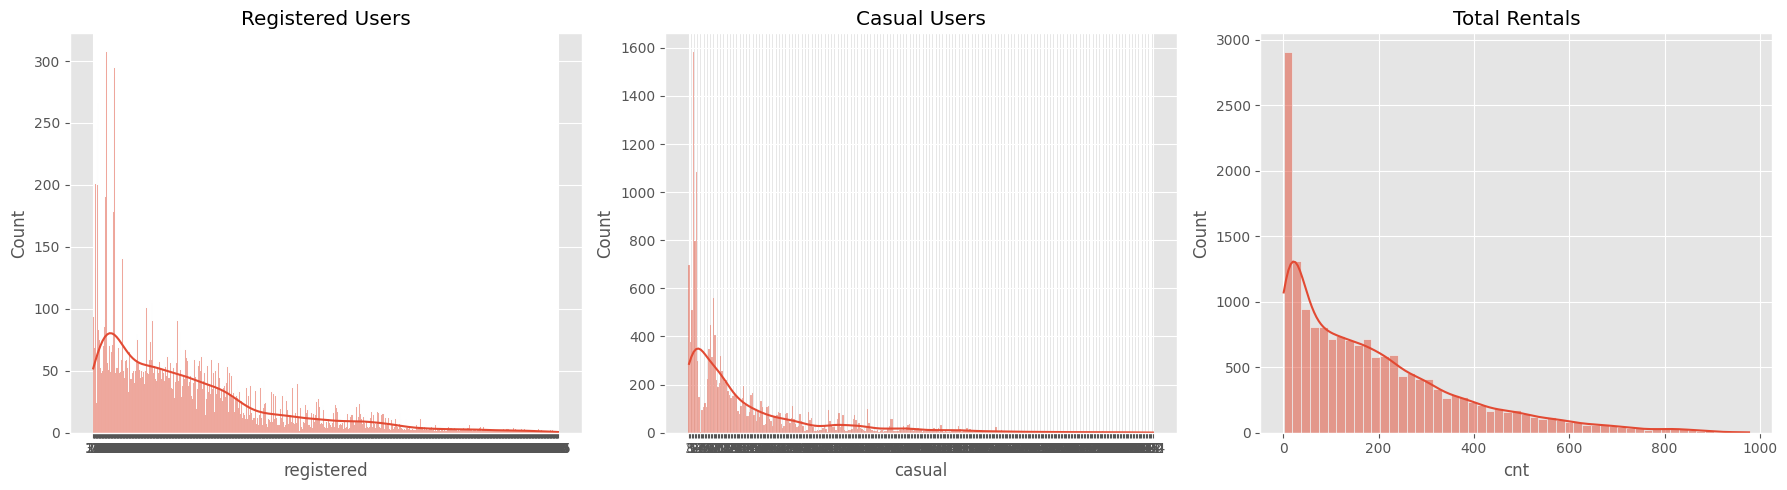

In [52]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(df['registered'], ax=axes[0], kde=True)
axes[0].set_title("Registered Users")

sns.histplot(df['casual'], ax=axes[1], kde=True)
axes[1].set_title("Casual Users")

sns.histplot(df['cnt'], ax=axes[2], kde=True)
axes[2].set_title("Total Rentals")

plt.tight_layout()

plt.show()

Feature Engineering

In [53]:
df_fe = df.copy()
df_fe.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,2011-01-01,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,2011-01-01,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,2011-01-01,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,2011-01-01,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


Extract Features from Date

In [54]:
df_fe['Year'] = df_fe['dteday'].dt.year
df_fe['Month_Name'] = df_fe['dteday'].dt.month_name()
df_fe['Day'] = df_fe['dteday'].dt.day
df_fe['Day_Name'] = df_fe['dteday'].dt.day_name()
df_fe['Week_Number'] = df_fe['dteday'].dt.isocalendar().week.astype(int)
df_fe['Quarter'] = df_fe['dteday'].dt.quarter

df_fe.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Month_Name,Day,Day_Name,Week_Number,Quarter
0,1,2011-01-01,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16,2011,January,1,Saturday,52,1
1,2,2011-01-01,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40,2011,January,1,Saturday,52,1
2,3,2011-01-01,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32,2011,January,1,Saturday,52,1
3,4,2011-01-01,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13,2011,January,1,Saturday,52,1
4,5,2011-01-01,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1,2011,January,1,Saturday,52,1


Create Peak Hour Feature

In [55]:
def peak_hour(hour):
    if hour in [7,8,9,17,18,19]:
        return 1
    else:
        return 0

df_fe['Peak_Hour'] = df_fe['hr'].apply(peak_hour)

df_fe[['hr','Peak_Hour']].head(10)

,hr,Peak_Hour
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,1
8,8,1
9,9,1


Weekend Feature

In [56]:
df_fe['Weekend'] = df_fe['weekday'].apply(lambda x: 1 if x in [0,6] else 0)

df_fe[['weekday','Weekend']].head()

,weekday,Weekend
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1


Temperature Difference

Difference between actual temperature and feeling temperature.

In [58]:
df_fe['temp'] = df_fe['temp'].replace('?', np.nan).astype(float)
df_fe['atemp'] = df_fe['atemp'].replace('?', np.nan).astype(float)

df_fe['Temp_Difference'] = abs(df_fe['temp'] - df_fe['atemp'])

df_fe[['temp','atemp','Temp_Difference']].head()

,temp,atemp,Temp_Difference
0,0.24,0.2879,0.0479
1,0.22,0.2727,0.0527
2,0.22,0.2727,0.0527
3,0.24,0.2879,0.0479
4,0.24,0.2879,0.0479


Weather Category

In [59]:
weather_map = {
    1:'Clear',
    2:'Mist',
    3:'Light Snow/Rain',
    4:'Heavy Rain'
}

df_fe['Weather_Category'] = df_fe['weathersit'].map(weather_map)

df_fe[['weathersit','Weather_Category']].head()

,weathersit,Weather_Category
0,Clear,NaN
1,Clear,NaN
2,Clear,NaN
3,Clear,NaN
4,Clear,NaN


Season Name

In [60]:
season_map = {
    1:'Spring',
    2:'Summer',
    3:'Fall',
    4:'Winter'
}

df_fe['Season_Name'] = df_fe['season'].map(season_map)

df_fe[['season','Season_Name']].head()

,season,Season_Name
0,springer,NaN
1,springer,NaN
2,springer,NaN
3,springer,NaN
4,springer,NaN


Month Name

In [61]:
month_map = {
1:'Jan',2:'Feb',3:'Mar',4:'Apr',
5:'May',6:'Jun',7:'Jul',8:'Aug',
9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}

df_fe['Month'] = df_fe['mnth'].map(month_map)

df_fe[['mnth','Month']].head()

,mnth,Month
0,1,NaN
1,1,NaN
2,1,NaN
3,1,NaN
4,1,NaN


One-Hot Encoding

In [62]:
categorical_columns = [
    'season',
    'weathersit',
    'Month_Name',
    'Day_Name'
]

df_fe = pd.get_dummies(
    df_fe,
    columns=categorical_columns,
    drop_first=True
)

df_fe.head()

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,1,2011-01-01,2011,1,0,No,6,No work,0.24,0.2879,0.81,0,3,13,16,2011,1,52,1,0,1,0.0479,NaN,NaN,NaN,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2,2011-01-01,2011,1,1,No,6,No work,0.22,0.2727,0.8,0,8,32,40,2011,1,52,1,0,1,0.0527,NaN,NaN,NaN,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,3,2011-01-01,2011,1,2,No,6,No work,0.22,0.2727,?,0,5,27,32,2011,1,52,1,0,1,0.0527,NaN,NaN,NaN,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,4,2011-01-01,2011,1,3,No,6,No work,0.24,0.2879,0.75,0,3,10,13,2011,1,52,1,0,1,0.0479,NaN,NaN,NaN,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,5,2011-01-01,2011,1,4,No,6,No work,0.24,0.2879,0.75,0,0,1,1,2011,1,52,1,0,1,0.0479,NaN,NaN,NaN,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


Label Encoding

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_fe['Season_Name'] = le.fit_transform(df_fe['Season_Name'])
df_fe['Weather_Category'] = le.fit_transform(df_fe['Weather_Category'])
df_fe['Month'] = le.fit_transform(df_fe['Month'])

df_fe.head()

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,1,2011-01-01,2011,1,0,No,6,No work,0.24,0.2879,0.81,0,3,13,16,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2,2011-01-01,2011,1,1,No,6,No work,0.22,0.2727,0.8,0,8,32,40,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,3,2011-01-01,2011,1,2,No,6,No work,0.22,0.2727,?,0,5,27,32,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,4,2011-01-01,2011,1,3,No,6,No work,0.24,0.2879,0.75,0,3,10,13,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,5,2011-01-01,2011,1,4,No,6,No work,0.24,0.2879,0.75,0,0,1,1,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


Feature Scaling

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_columns = [
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

# Convert 'hum' and 'windspeed' to float, handling '?' values
df_fe['hum'] = df_fe['hum'].replace('?', np.nan).astype(float)
df_fe['windspeed'] = df_fe['windspeed'].replace('?', np.nan).astype(float)

df_fe[scale_columns] = scaler.fit_transform(df_fe[scale_columns])

df_fe.head()

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,1,2011-01-01,2011,1,0,No,6,No work,-1.335615,-1.093858,0.947437,-1.553996,3,13,16,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2,2011-01-01,2011,1,1,No,6,No work,-1.439500,-1.182321,0.895606,-1.553996,8,32,40,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,3,2011-01-01,2011,1,2,No,6,No work,-1.439500,-1.182321,NaN,-1.553996,5,27,32,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,4,2011-01-01,2011,1,3,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,3,10,13,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,5,2011-01-01,2011,1,4,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0,1,1,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


Min-Max Scaling

In [67]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

minmax_columns = [
    'casual',
    'registered'
]

# Convert 'casual' and 'registered' to float, handling '?' values
df_fe['casual'] = df_fe['casual'].replace('?', np.nan).astype(float)
df_fe['registered'] = df_fe['registered'].replace('?', np.nan).astype(float)

df_fe[minmax_columns] = mm.fit_transform(df_fe[minmax_columns])
df_fe.head()

,instant,dteday,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,1,2011-01-01,2011,1,0,No,6,No work,-1.335615,-1.093858,0.947437,-1.553996,0.008174,0.014673,16,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2,2011-01-01,2011,1,1,No,6,No work,-1.439500,-1.182321,0.895606,-1.553996,0.021798,0.036117,40,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,3,2011-01-01,2011,1,2,No,6,No work,-1.439500,-1.182321,NaN,-1.553996,0.013624,0.030474,32,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,4,2011-01-01,2011,1,3,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0.008174,0.011287,13,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,5,2011-01-01,2011,1,4,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0.000000,0.001129,1,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


Drop Unnecessary Columns

In [70]:
drop_columns = [
    'instant',
    'dteday'
]

df_fe.drop(columns=drop_columns, inplace=True, errors='ignore')
df_fe.head()

,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,2011,1,0,No,6,No work,-1.335615,-1.093858,0.947437,-1.553996,0.008174,0.014673,16,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2011,1,1,No,6,No work,-1.439500,-1.182321,0.895606,-1.553996,0.021798,0.036117,40,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,2011,1,2,No,6,No work,-1.439500,-1.182321,NaN,-1.553996,0.013624,0.030474,32,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,2011,1,3,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0.008174,0.011287,13,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,2011,1,4,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0.000000,0.001129,1,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


Check Final Dataset

In [71]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     17379 non-null  object 
 1   mnth                   17379 non-null  object 
 2   hr                     17379 non-null  int64  
 3   holiday                17379 non-null  object 
 4   weekday                17379 non-null  int64  
 5   workingday             17379 non-null  object 
 6   temp                   17368 non-null  float64
 7   atemp                  17373 non-null  float64
 8   hum                    17373 non-null  float64
 9   windspeed              17374 non-null  float64
 10  casual                 17378 non-null  float64
 11  registered             17378 non-null  float64
 12  cnt                    17379 non-null  int64  
 13  Year                   17379 non-null  int32  
 14  Day                    17379 non-null  int32  
 15  We

Check Final Dataset

In [72]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     17379 non-null  object 
 1   mnth                   17379 non-null  object 
 2   hr                     17379 non-null  int64  
 3   holiday                17379 non-null  object 
 4   weekday                17379 non-null  int64  
 5   workingday             17379 non-null  object 
 6   temp                   17368 non-null  float64
 7   atemp                  17373 non-null  float64
 8   hum                    17373 non-null  float64
 9   windspeed              17374 non-null  float64
 10  casual                 17378 non-null  float64
 11  registered             17378 non-null  float64
 12  cnt                    17379 non-null  int64  
 13  Year                   17379 non-null  int32  
 14  Day                    17379 non-null  int32  
 15  We

Check Missing Values Again

In [73]:
df_fe.isnull().sum()

,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
temp,11
atemp,6
hum,6
windspeed,5


Check Data Types

In [74]:
df_fe.dtypes

,0
yr,object
mnth,object
hr,int64
holiday,object
weekday,int64
workingday,object
temp,float64
atemp,float64
hum,float64
windspeed,float64


Save Engineered Dataset

In [75]:
df_fe.to_csv("BikeRental_Feature_Engineered.csv", index=False)
print("Feature Engineered Dataset Saved Successfully")

Feature Engineered Dataset Saved Successfully


Display Final Dataset

In [76]:
df_fe.head()

,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday
0,2011,1,0,No,6,No work,-1.335615,-1.093858,0.947437,-1.553996,0.008174,0.014673,16,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,2011,1,1,No,6,No work,-1.439500,-1.182321,0.895606,-1.553996,0.021798,0.036117,40,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,2011,1,2,No,6,No work,-1.439500,-1.182321,NaN,-1.553996,0.013624,0.030474,32,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
3,2011,1,3,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0.008174,0.011287,13,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
4,2011,1,4,No,6,No work,-1.335615,-1.093858,0.636449,-1.553996,0.000000,0.001129,1,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False


Final Shape

In [77]:
print("Original Shape :", df.shape)
print("Feature Engineered Shape :", df_fe.shape)

Original Shape : (17379, 17)
Feature Engineered Shape : (17379, 48)


Model Building

Import Libraries

In [78]:
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

Define Features and Target

In [79]:
X = df_fe.drop('cnt', axis=1)

y = df_fe['cnt']

print(X.shape)
print(y.shape)

(17379, 47)
(17379,)


Convert Categorical Columns (if any remain)

In [80]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,hr,weekday,temp,atemp,hum,windspeed,casual,registered,Year,Day,Week_Number,Quarter,Peak_Hour,Weekend,Temp_Difference,Weather_Category,Season_Name,Month,season_fall,season_springer,season_summer,season_winter,weathersit_Clear,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist,Month_Name_August,Month_Name_December,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Day_Name_Monday,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday,yr_2012,yr_?,mnth_10,mnth_11,mnth_12,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_?,holiday_No,holiday_Yes,workingday_No work,workingday_Working Day
0,0,6,-1.335615,-1.093858,0.947437,-1.553996,0.008174,0.014673,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,1,6,-1.439500,-1.182321,0.895606,-1.553996,0.021798,0.036117,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
2,2,6,-1.439500,-1.182321,NaN,-1.553996,0.013624,0.030474,2011,1,52,1,0,1,0.0527,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
3,3,6,-1.335615,-1.093858,0.636449,-1.553996,0.008174,0.011287,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
4,4,6,-1.335615,-1.093858,0.636449,-1.553996,0.000000,0.001129,2011,1,52,1,0,1,0.0479,0,0,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


Train-Test Split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (13903, 61)
Testing Shape : (3476, 61)


Train Decision Tree Regressor

In [82]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

Decision Tree Prediction

In [83]:
dt_pred = dt_model.predict(X_test)

Decision Tree Evaluation

In [84]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE :", dt_rmse)
print("R2 Score :", dt_r2)

Decision Tree Results
MAE : 2.2986191024165707
MSE : 23.428653624856157
RMSE : 4.840315446833621
R2 Score : 0.9992601184498784


Train Random Forest

In [85]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Random Forest Prediction

In [86]:
rf_pred = rf_model.predict(X_test)

Random Forest Evaluation

In [87]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
MAE : 0.9973388952819331
MSE : 7.708118498273877
RMSE : 2.776349851562997
R2 Score : 0.9997565760818209


Train Gradient Boosting

In [89]:
from sklearn.impute import SimpleImputer

# Identify numerical columns that still contain NaNs
nan_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'Temp_Difference']

# Instantiate the imputer with mean strategy
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on X_train and transform both X_train and X_test
X_train[nan_cols] = imputer.fit_transform(X_train[nan_cols])
X_test[nan_cols] = imputer.transform(X_test[nan_cols])

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

Gradient Boosting Prediction

In [90]:
gb_pred = gb_model.predict(X_test)

Gradient Boosting Evaluation

In [91]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("MAE :", gb_mae)
print("MSE :", gb_mse)
print("RMSE :", gb_rmse)
print("R2 Score :", gb_r2)

Gradient Boosting Results
MAE : 3.0648317762777637
MSE : 25.39803645328974
RMSE : 5.039646461140874
R2 Score : 0.9991979249477158


Compare All Models

In [92]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        dt_mae,
        rf_mae,
        gb_mae
    ],

    "MSE":[
        dt_mse,
        rf_mse,
        gb_mse
    ],

    "RMSE":[
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2 Score":[
        dt_r2,
        rf_r2,
        gb_r2
    ]

})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Decision Tree,2.298619,23.428654,4.840315,0.999260
1,Random Forest,0.997339,7.708118,2.776350,0.999757
2,Gradient Boosting,3.064832,25.398036,5.039646,0.999198


Best Model

In [93]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
1,Random Forest,0.997339,7.708118,2.776350,0.999757
0,Decision Tree,2.298619,23.428654,4.840315,0.999260
2,Gradient Boosting,3.064832,25.398036,5.039646,0.999198


Feature Importance (Random Forest)

In [94]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
7,registered,0.947430
6,casual,0.051140
59,workingday_No work,0.000196
10,Week_Number,0.000168
60,workingday_Working Day,0.000140
5,windspeed,0.000114
29,Month_Name_January,0.000104
43,yr_2012,0.000090
1,weekday,0.000082
13,Weekend,0.000071


Plot Feature Importance

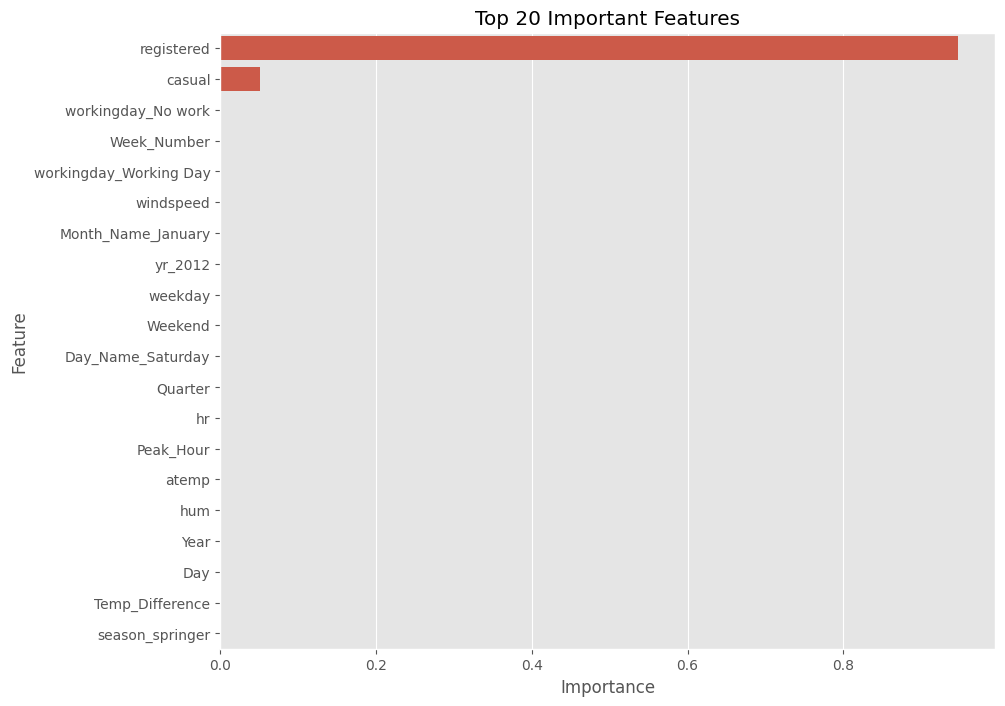

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()

Actual vs Predicted (Random Forest)

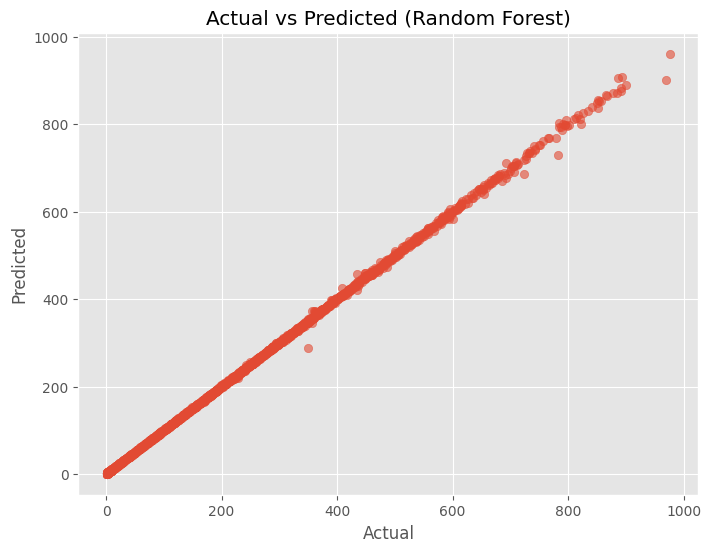

In [96]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.6
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted (Random Forest)")

plt.show()

Residual Plot

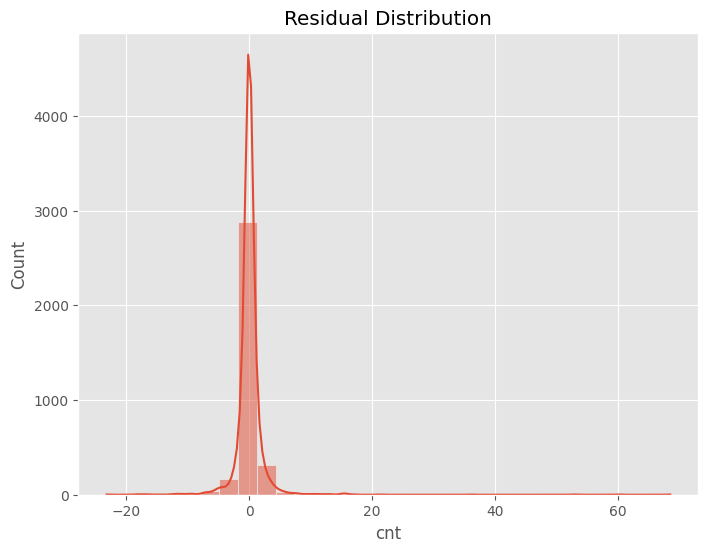

In [97]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

Save Best Model

In [98]:
import joblib

joblib.dump(
    rf_model,
    "BikeRental_RF_Model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


Hyperparameter Tuning

Import Libraries

In [99]:
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

Decision Tree Parameter Grid

In [100]:
dt_params = {

    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'criterion':['squared_error','friedman_mse']

}

Decision Tree Grid Search

In [101]:
dt_grid = GridSearchCV(

    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2

)

dt_grid.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2', verbose=2)

Best Parameters

In [102]:
print(dt_grid.best_params_)
print(dt_grid.best_score_)

{'criterion': 'friedman_mse', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
0.9990313308943103


Tuned Decision Tree Evaluation

In [104]:
best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :",dt_mae)
print("MSE :",dt_mse)
print("RMSE :",dt_rmse)
print("R2 :",dt_r2)

Decision Tree
MAE : 2.395668255794838
MSE : 29.175217598355022
RMSE : 5.401408853100738
R2 : 0.9990786408144724


Random Forest Parameter Grid

In [105]:
rf_params = {

    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt','log2']

}

Random Forest Grid Search

In [107]:
rf_grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2

)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

Best Parameters

In [108]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.9843395775286616


Tuned Random Forest Evaluation

In [110]:
best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_mse = mean_squared_error(y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest")
print("MAE :",rf_mae)
print("MSE :",rf_mse)
print("RMSE :",rf_rmse)
print("R2 :",rf_r2)

Random Forest
MAE : 12.862520617568086
MSE : 416.8641297032828
RMSE : 20.41725078709871
R2 : 0.9868353477150842


Gradient Boosting Parameter Grid

In [111]:
gb_params = {

    'n_estimators':[100,200],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5],
    'subsample':[0.8,1.0],
    'min_samples_split':[2,5]

}

Gradient Boosting Grid Search

In [114]:
gb_grid = GridSearchCV(

    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2

)

gb_grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5], 'min_samples_split': [2, 5],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='r2', verbose=2)

Best Parameters

In [115]:
print(gb_grid.best_params_)
print(gb_grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}
0.9997748929715151


Tuned Gradient Boosting Evaluation

In [116]:
best_gb = gb_grid.best_estimator_

gb_pred = best_gb.predict(X_test)
gb_mae = mean_absolute_error(y_test,gb_pred)
gb_mse = mean_squared_error(y_test,gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test,gb_pred)

print("Gradient Boosting")
print("MAE :",gb_mae)
print("MSE :",gb_mse)
print("RMSE :",gb_rmse)
print("R2 :",gb_r2)

Gradient Boosting
MAE : 1.3013660224232573
MSE : 6.007977287690589
RMSE : 2.451117558929108
R2 : 0.9998102668800397


Compare Tuned Models

In [117]:
tuned_results = pd.DataFrame({

    'Model':[
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE':[
        dt_mae,
        rf_mae,
        gb_mae
    ],

    'MSE':[
        dt_mse,
        rf_mse,
        gb_mse
    ],

    'RMSE':[
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],

    'R2 Score':[
        dt_r2,
        rf_r2,
        gb_r2
    ]

})

tuned_results

,Model,MAE,MSE,RMSE,R2 Score
0,Decision Tree,2.395668,29.175218,5.401409,0.999079
1,Random Forest,12.862521,416.864130,20.417251,0.986835
2,Gradient Boosting,1.301366,6.007977,2.451118,0.999810


Best Tuned Model

In [118]:
tuned_results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Gradient Boosting,1.301366,6.007977,2.451118,0.999810
0,Decision Tree,2.395668,29.175218,5.401409,0.999079
1,Random Forest,12.862521,416.864130,20.417251,0.986835


Best Hyperparameters

In [119]:
print("Decision Tree Best Parameters")
print(dt_grid.best_params_)

print()

print("Random Forest Best Parameters")
print(rf_grid.best_params_)

print()

print("Gradient Boosting Best Parameters")
print(gb_grid.best_params_)

Decision Tree Best Parameters
{'criterion': 'friedman_mse', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}

Random Forest Best Parameters
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Gradient Boosting Best Parameters
{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


Save Best Model

In [120]:
import joblib

joblib.dump(best_rf,'Best_BikeRental_Model.pkl')

print("Best Model Saved Successfully")

Best Model Saved Successfully


Cross-Validation Scores

In [121]:
print("Decision Tree CV Score :",dt_grid.best_score_)
print("Random Forest CV Score :",rf_grid.best_score_)
print("Gradient Boosting CV Score :",gb_grid.best_score_)

Decision Tree CV Score : 0.9990313308943103
Random Forest CV Score : 0.9843395775286616
Gradient Boosting CV Score : 0.9997748929715151


Feature Importance (Best Random Forest)

In [122]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':best_rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
7,registered,0.370559
6,casual,0.185058
0,hr,0.119547
12,Peak_Hour,0.072061
3,atemp,0.034035
2,temp,0.029983
4,hum,0.025915
8,Year,0.020964
43,yr_2012,0.018502
10,Week_Number,0.013546


Plot Feature Importance

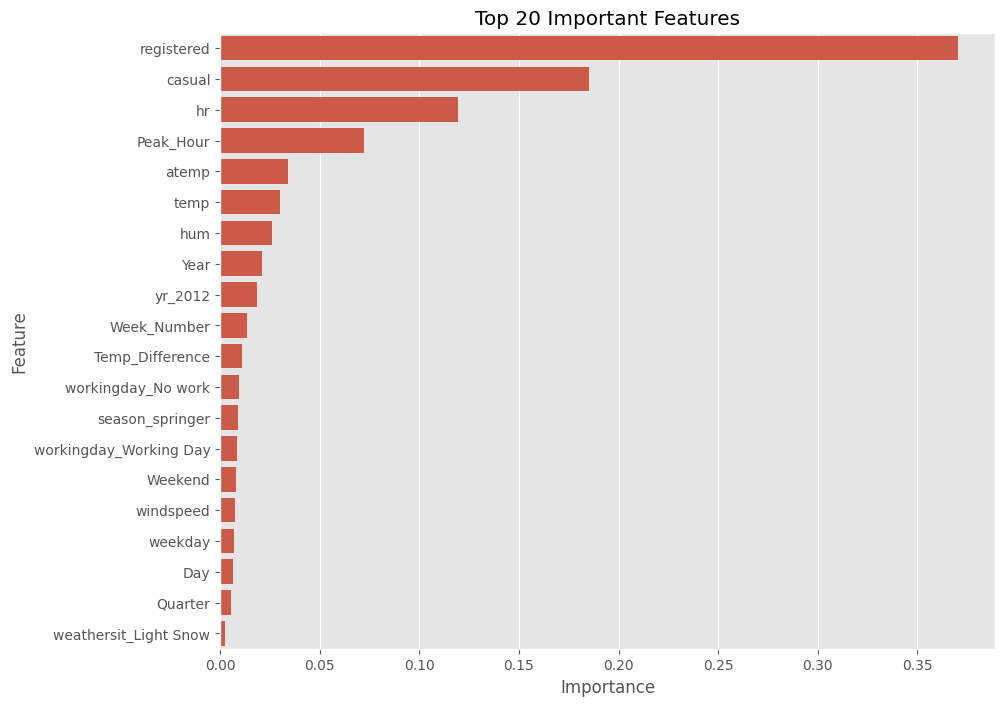

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x='Importance',

    y='Feature'

)

plt.title("Top 20 Important Features")

plt.show()

Model Evaluation

Import Libraries

In [124]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Evaluation Function

In [125]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({

        "Model":[model_name],
        "MAE":[mae],
        "MSE":[mse],
        "RMSE":[rmse],
        "R2 Score":[r2]

    })

Evaluation Function

In [126]:
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({

        "Model":[model_name],
        "MAE":[mae],
        "MSE":[mse],
        "RMSE":[rmse],
        "R2 Score":[r2]

    })

Evaluate All Models

In [127]:
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    best_dt.predict(X_test)
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    best_rf.predict(X_test)
)

gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    best_gb.predict(X_test)
)

Comparison Table

In [128]:
evaluation = pd.concat([
    dt_results,
    rf_results,
    gb_results
], ignore_index=True)

evaluation

,Model,MAE,MSE,RMSE,R2 Score
0,Decision Tree,2.395668,29.175218,5.401409,0.999079
1,Random Forest,12.862521,416.864130,20.417251,0.986835
2,Gradient Boosting,1.301366,6.007977,2.451118,0.999810


Best Model

In [129]:
evaluation.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,Gradient Boosting,1.301366,6.007977,2.451118,0.999810
0,Decision Tree,2.395668,29.175218,5.401409,0.999079
1,Random Forest,12.862521,416.864130,20.417251,0.986835


Actual vs Predicted (Random Forest)

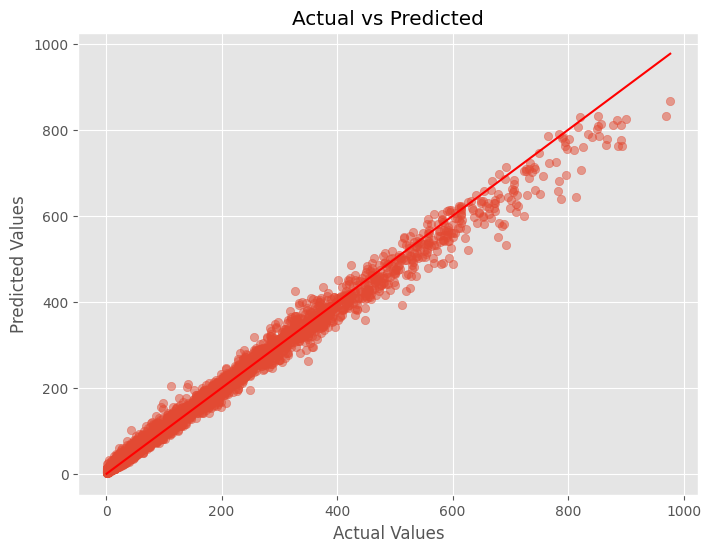

In [130]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_rf.predict(X_test),
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

Residual Plot

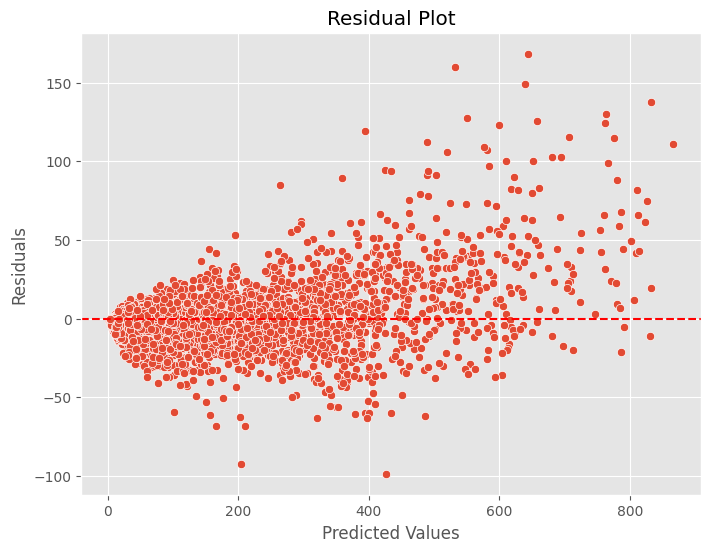

In [131]:
residuals = y_test - best_rf.predict(X_test)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=best_rf.predict(X_test),
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Residual Distribution

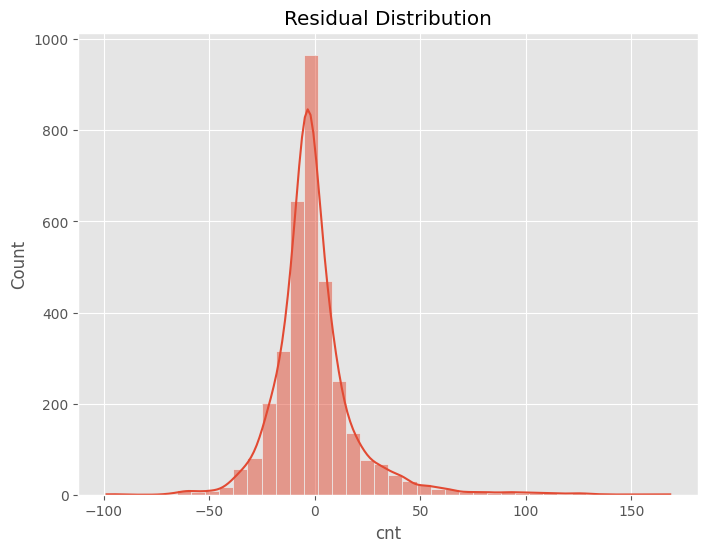

In [132]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")
plt.show()

QQ Plot

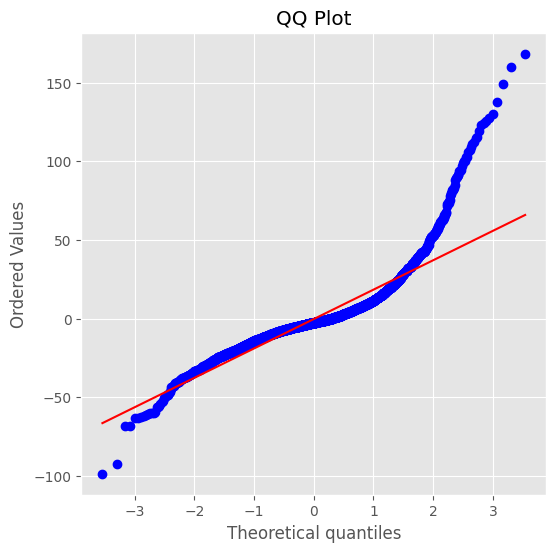

In [133]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot")

plt.show()

Error Distribution

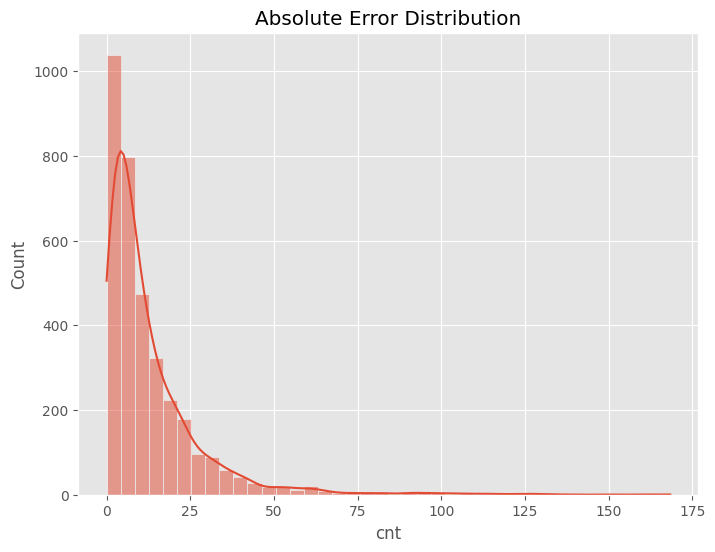

In [134]:
errors = abs(
    y_test - best_rf.predict(X_test)
)

plt.figure(figsize=(8,6))

sns.histplot(
    errors,
    bins=40,
    kde=True
)

plt.title("Absolute Error Distribution")

plt.show()

Prediction vs Residual

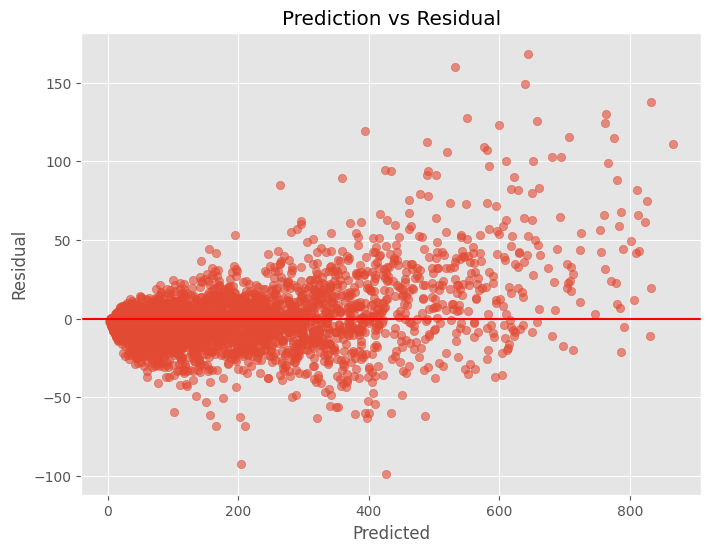

In [135]:
plt.figure(figsize=(8,6))

plt.scatter(
    best_rf.predict(X_test),
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red'
)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Prediction vs Residual")
plt.show()

Top 20 Feature Importance

In [136]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
7,registered,0.370559
6,casual,0.185058
0,hr,0.119547
12,Peak_Hour,0.072061
3,atemp,0.034035
2,temp,0.029983
4,hum,0.025915
8,Year,0.020964
43,yr_2012,0.018502
10,Week_Number,0.013546


Feature Importance Plot

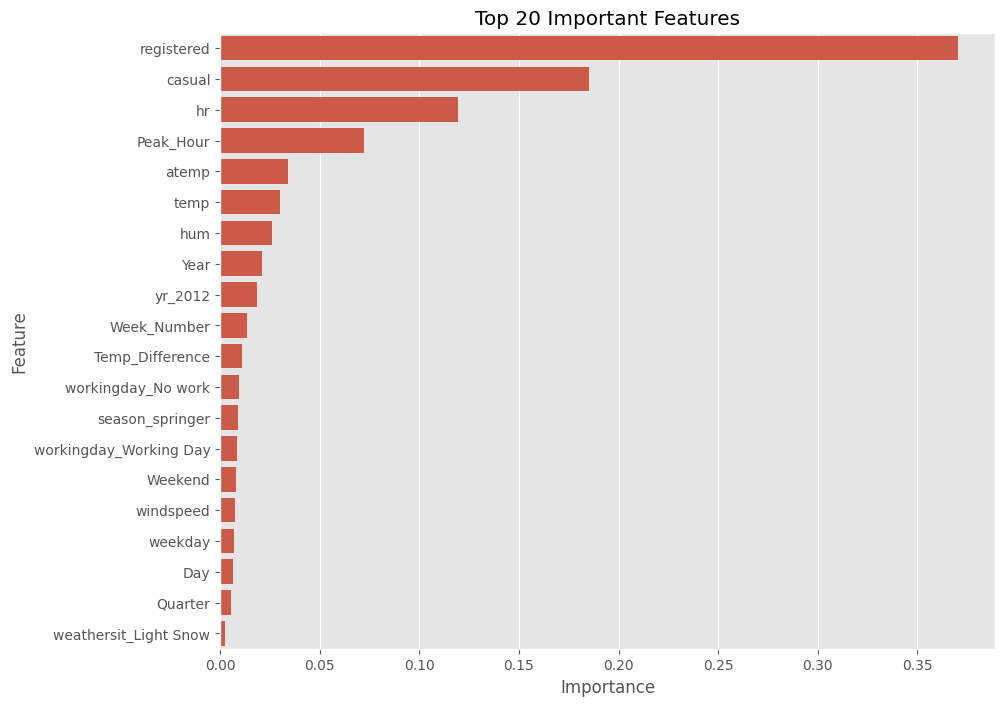

In [137]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),
    x="Importance",
    y="Feature"

)

plt.title("Top 20 Important Features")
plt.show()

Prediction Table

In [138]:
prediction_df = pd.DataFrame({

    "Actual":y_test,
    "Predicted":best_rf.predict(X_test)

})

prediction_df.head(20)

,Actual,Predicted
12830,425,420.225
8688,88,88.235
7091,4,11.170
12230,526,554.495
431,13,17.430
1086,32,39.095
11605,706,659.450
7983,26,40.465
10391,2,10.880
7046,21,18.685


Prediction Error

In [139]:
prediction_df["Error"] = (

    prediction_df["Actual"]

    -

    prediction_df["Predicted"]

)

prediction_df.head(20)

,Actual,Predicted,Error
12830,425,420.225,4.775
8688,88,88.235,-0.235
7091,4,11.170,-7.170
12230,526,554.495,-28.495
431,13,17.430,-4.430
1086,32,39.095,-7.095
11605,706,659.450,46.550
7983,26,40.465,-14.465
10391,2,10.880,-8.880
7046,21,18.685,2.315


Save Prediction Results

In [140]:
prediction_df.to_csv(

    "Prediction_Results.csv",
    index=False

)

print("Prediction Results Saved Successfully")

Prediction Results Saved Successfully


Save Evaluation Report

In [141]:
evaluation.to_csv(

    "Model_Evaluation.csv",
    index=False

)

print("Evaluation Report Saved Successfully")

Evaluation Report Saved Successfully


Final Performance Summary

In [142]:
print("="*50)
print("FINAL MODEL PERFORMANCE")
print("="*50)
print(evaluation)
print("="*50)

FINAL MODEL PERFORMANCE
               Model        MAE         MSE       RMSE  R2 Score
0      Decision Tree   2.395668   29.175218   5.401409  0.999079
1      Random Forest  12.862521  416.864130  20.417251  0.986835
2  Gradient Boosting   1.301366    6.007977   2.451118  0.999810


Best Model Name

In [143]:
best_model = evaluation.loc[
    evaluation["R2 Score"].idxmax()
]

print(best_model)

Model       Gradient Boosting
MAE                  1.301366
MSE                  6.007977
RMSE                 2.451118
R2 Score              0.99981
Name: 2, dtype: object


Final Conclusion

In [145]:
print("Best Model :", best_model["Model"])

print("Best R2 Score :", best_model["R2 Score"])

print("Lowest RMSE :", best_model["RMSE"])

Best Model : Gradient Boosting
Best R2 Score : 0.9998102668800397
Lowest RMSE : 2.451117558929108


Model Deployment (Streamlit)

Install Streamlit

In [146]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 26.0 MB/s eta 0:00:00


Save the Best Model

In [147]:
import joblib

joblib.dump(best_rf, "BikeRental_Model.pkl")

['BikeRental_Model.pkl']

Save Feature Columns

In [148]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

Create app.py

In [149]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load Model
model = joblib.load("BikeRental_Model.pkl")

# Load Feature Names
feature_columns = joblib.load("feature_columns.pkl")

st.title("🚲 Bike Rental Demand Prediction")

st.write("Enter the feature values below.")

user_input = {}

for feature in feature_columns:

    user_input[feature] = st.number_input(
        feature,
        value=0.0
    )

input_df = pd.DataFrame([user_input])

prediction = model.predict(input_df)

st.subheader("Predicted Bike Rentals")

st.success(f"{prediction[0]:.2f}")

Writing app.py


Run Streamlit


In [153]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 5s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠏

In [154]:
!streamlit run app.py &>/content/logs.txt &

In [163]:
!npx localtunnel --port 8501

⠙your url is: https://clean-cows-attend.loca.lt
^C


In [164]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
